# Hybrid Negative Binomial: Deep Dive

Данный ноутбук представляет собой полное и прозрачное руководство по реализации
модели **Hybrid NB** для прогнозирования сейсмической активности в Центральной Азии.

Все этапы — от загрузки сырых данных до верификации обратного распространения
ошибки — выполняются пошагово с визуализацией промежуточных результатов.

> **Из `src/` импортируются только** `EarthquakeNet` и `NBLoss`; весь остальной
> код воспроизведён явно в ячейках ноутбука.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance
from scipy.special import digamma, gammaln
from torch.utils.data import DataLoader

from src.dl_modeling import EarthquakeNet, EarthquakeDataset, NBLoss

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


---
## 1. Ручной конвейер обработки данных

В этом разделе мы **воспроизводим** полный пайплайн подготовки данных без
использования модулей `data_ingestion` и `grid_builder`, чтобы сделать
каждый шаг преобразования прозрачным.

### 1.1 Загрузка сырых данных с USGS

Запрос к [USGS FDSN API](https://earthquake.usgs.gov/fdsnws/event/1/) для
региона Центральной Азии ($38°$–$45°$ с.ш., $65°$–$85°$ в.д.),
$M \geq 3.0$, период 2010–2024 гг.

In [2]:
BASE_URL = "https://earthquake.usgs.gov/fdsnws/event/1/query"
PARAMS = {
    "format": "csv",
    "starttime": "2010-01-01",
    "endtime": "2024-01-01",
    "minmagnitude": 3.0,
    "minlatitude": 38.0, "maxlatitude": 45.0,
    "minlongitude": 65.0, "maxlongitude": 85.0,
}

response = requests.get(BASE_URL, params=PARAMS, timeout=60)
response.raise_for_status()
raw = pd.read_csv(io.StringIO(response.text))
print(f"Скачано событий: {len(raw):,}")
raw.head()

Скачано событий: 1,607


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2023-12-27T09:00:05.608Z,38.6772,73.6254,102.533,4.2,mb,25.0,125.0,1.631,0.29,...,2024-03-02T21:39:32.040Z,"63 km NNW of Murghob, Tajikistan",earthquake,7.67,8.128,0.176,9.0,reviewed,us,us
1,2023-12-19T01:46:21.061Z,39.9543,77.8492,10.000,5.2,mww,108.0,64.0,1.623,0.56,...,2024-02-27T22:57:01.040Z,"104 km W of Tumxuk, China",earthquake,6.39,1.762,0.098,10.0,reviewed,us,us
2,2023-12-14T07:59:53.158Z,40.1487,71.5187,10.000,4.1,mb,19.0,89.0,0.545,0.31,...,2024-02-17T22:43:09.040Z,"12 km SW of Khalmion, Kyrgyzstan",earthquake,3.00,1.975,0.184,8.0,reviewed,us,us
3,2023-12-13T05:13:05.131Z,40.3395,65.6233,10.000,4.2,mb,32.0,96.0,1.618,0.73,...,2024-02-17T22:43:07.040Z,"25 km SSW of Nurota, Uzbekistan",earthquake,4.09,1.889,0.265,4.0,reviewed,us,us
4,2023-11-29T10:59:37.488Z,38.4230,73.8447,128.307,4.4,mb,40.0,66.0,1.911,0.56,...,2024-02-06T21:53:54.040Z,"30 km NNW of Murghob, Tajikistan",earthquake,5.66,7.906,0.120,20.0,reviewed,us,us


### 1.2 Очистка данных

Оставляем только необходимые столбцы, удаляем строки с пропусками,
приводим типы и сортируем хронологически.

In [3]:
COLS = ["time", "latitude", "longitude", "depth", "mag", "place"]
df = raw[COLS].copy()
df = df.dropna(subset=["time", "latitude", "longitude", "mag"])
for c in ("latitude", "longitude", "depth", "mag"):
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["latitude", "longitude", "mag"])
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values("time").reset_index(drop=True)

print(f"После очистки: {len(df):,} событий")
df.head()

После очистки: 1,607 событий


,time,latitude,longitude,depth,mag,place
0,2010-01-02 02:15:12.090000+00:00,38.245,71.467,47.0,5.4,"84 km N of Khorugh, Tajikistan"
1,2010-01-02 03:12:14.380000+00:00,38.362,71.318,42.7,4.4,"98 km S of Karakenja, Tajikistan"
2,2010-01-02 04:49:04.540000+00:00,38.452,71.291,48.6,4.3,"89 km SSW of Karakenja, Tajikistan"
3,2010-01-02 15:22:46.990000+00:00,40.715,79.660,48.2,4.8,"48 km SW of Aykol, China"
4,2010-01-06 05:36:30.030000+00:00,38.031,70.449,35.0,4.8,"37 km ESE of M?’minobod, Tajikistan"


### 1.3 Формирование пространственных ячеек

Координаты событий квантуются в ячейки $3° \times 3°$. Каждой ячейке
присваивается строковый идентификатор `cell_id = "<lat_grid>_<lon_grid>"`.

In [4]:
GRID_SIZE = 3.0
MIN_LAT, MIN_LON = 38.0, 65.0

lat = df["latitude"].to_numpy(dtype=float)
lon = df["longitude"].to_numpy(dtype=float)

df["lat_grid"] = np.round(np.floor((lat - MIN_LAT) / GRID_SIZE) * GRID_SIZE + MIN_LAT, 2)
df["lon_grid"] = np.round(np.floor((lon - MIN_LON) / GRID_SIZE) * GRID_SIZE + MIN_LON, 2)
df["cell_id"] = (
    df["lat_grid"].map(lambda x: f"{x:.2f}")
    + "_"
    + df["lon_grid"].map(lambda x: f"{x:.2f}")
)
df["energy"] = 10 ** (1.5 * df["mag"])
df["week"] = (
    df["time"].dt.tz_convert("UTC").dt.tz_localize(None)
    .dt.to_period("W").dt.start_time
)

n_cells = df["cell_id"].nunique()
print(f"Уникальных ячеек: {n_cells}")
df[["cell_id", "lat_grid", "lon_grid", "week", "mag", "energy"]].head(8)

Уникальных ячеек: 17


,cell_id,lat_grid,lon_grid,week,mag,energy
0,38.00_71.00,38.0,71.0,2009-12-28,5.4,1.258925e+08
1,38.00_71.00,38.0,71.0,2009-12-28,4.4,3.981072e+06
2,38.00_71.00,38.0,71.0,2009-12-28,4.3,2.818383e+06
3,38.00_77.00,38.0,77.0,2009-12-28,4.8,1.584893e+07
4,38.00_68.00,38.0,68.0,2010-01-04,4.8,1.584893e+07
5,38.00_74.00,38.0,74.0,2010-01-04,4.5,5.623413e+06
6,38.00_65.00,38.0,65.0,2010-01-11,4.7,1.122018e+07
7,38.00_68.00,38.0,68.0,2010-01-11,4.5,5.623413e+06


### 1.4 Еженедельная агрегация

Для каждой пары $(\text{cell\_id},\;\text{week})$ вычисляем таргет $Y$
(число событий), $\text{mag\_max}$, $\text{mag\_min}$ и сумму энергий.

In [5]:
agg = (
    df.groupby(["cell_id", "lat_grid", "lon_grid", "week"], as_index=False)
    .agg(
        Y=("mag", "count"),
        mag_max=("mag", "max"),
        mag_min=("mag", "min"),
        energy_sum=("energy", "sum"),
    )
)
print(f"Строк после агрегации: {len(agg):,}  (только ненулевые недели)")
agg.head()

Строк после агрегации: 1,125  (только ненулевые недели)


,cell_id,lat_grid,lon_grid,week,Y,mag_max,mag_min,energy_sum
0,38.00_65.00,38.0,65.0,2010-01-11,1,4.7,4.7,1.122018e+07
1,38.00_65.00,38.0,65.0,2012-02-20,1,4.4,4.4,3.981072e+06
2,38.00_65.00,38.0,65.0,2012-04-16,1,4.8,4.8,1.584893e+07
3,38.00_65.00,38.0,65.0,2013-05-20,1,5.7,5.7,3.548134e+08
4,38.00_65.00,38.0,65.0,2014-04-28,1,4.5,4.5,5.623413e+06


### 1.5 Полная панель через `MultiIndex`

Создаём декартово произведение $\{\text{cell\_id}\} \times \{\text{weeks}\}$,
чтобы заполнить пропущенные (нулевые) недели. Итоговая размерность панели:

$$N = N_{\text{cells}} \times T_{\text{weeks}}$$

In [6]:
full_weeks = pd.date_range(agg["week"].min(), agg["week"].max(), freq="W-MON")
cells_df = agg[["cell_id", "lat_grid", "lon_grid"]].drop_duplicates("cell_id", keep="first")

full_idx = pd.MultiIndex.from_product(
    [cells_df["cell_id"].values, full_weeks], names=["cell_id", "week"]
)
panel = full_idx.to_frame(index=False).merge(cells_df, on="cell_id", how="left")
panel = panel.merge(agg, on=["cell_id", "lat_grid", "lon_grid", "week"], how="left")

for c in ("Y", "mag_max", "mag_min", "energy_sum"):
    panel[c] = panel[c].fillna(0.0)

Nc = panel["cell_id"].nunique()
T  = panel["week"].nunique()
print(f"N_cells = {Nc},  T_weeks = {T},  N_total = {len(panel):,}  (ожидается {Nc * T:,})")

N_cells = 17,  T_weeks = 731,  N_total = 12,427  (ожидается 12,427)


In [23]:
panel

,cell_id,week,lat_grid,lon_grid,Y,mag_max,mag_min,energy_sum,Y_lag1,mag_max_lag1,mag_min_lag1,mag_max_roll4,count_roll12,energy_roll8,weeks_since_m45
0,38.00_65.00,2009-12-28,38.0,65.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,500.0
1,38.00_65.00,2010-01-04,38.0,65.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,500.0
2,38.00_65.00,2010-01-11,38.0,65.0,1,4.7,4.7,1.122018e+07,0.0,0.0,0.0,0.0,0.0,0.000000e+00,500.0
3,38.00_65.00,2010-01-18,38.0,65.0,0,0.0,0.0,0.000000e+00,1.0,4.7,4.7,4.7,1.0,1.122018e+07,0.0
4,38.00_65.00,2010-01-25,38.0,65.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,4.7,1.0,1.122018e+07,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12422,44.00_83.00,2023-11-27,44.0,83.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,172.0
12423,44.00_83.00,2023-12-04,44.0,83.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,173.0
12424,44.00_83.00,2023-12-11,44.0,83.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,174.0
12425,44.00_83.00,2023-12-18,44.0,83.0,0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,175.0


### 1.6 Лаговые признаки с `.shift(1)`

Все признаки формируются **внутри каждой ячейки** со сдвигом на одну неделю,
чтобы исключить утечку информации из будущего. Вектор признаков
$\mathbf{x} \in \mathbb{R}^7$ (Enhanced-набор):

| Признак | Описание |
|:---|:---|
| `Y_lag1` | Число событий на прошлой неделе |
| `mag_max_lag1` | Максимальная магнитуда (лаг 1) |
| `mag_min_lag1` | Минимальная магнитуда (лаг 1) |
| `mag_max_roll4` | Скользящий максимум магнитуды (окно 4 нед.) |
| `count_roll12` | Скользящая сумма $Y$ (окно 12 нед.) |
| `energy_roll8` | Скользящая сумма энергии (окно 8 нед.) |
| `weeks_since_m45` | Недель с последнего события $M \geq 4.5$ |

In [7]:
panel = panel.sort_values(["cell_id", "week"]).reset_index(drop=True)
g = panel.groupby("cell_id", sort=False)

panel["Y_lag1"]        = g["Y"].shift(1).fillna(0.0)
panel["mag_max_lag1"]  = g["mag_max"].shift(1).fillna(0.0)
panel["mag_min_lag1"]  = g["mag_min"].shift(1).fillna(0.0)
panel["mag_max_roll4"] = g["mag_max"].transform(
    lambda s: s.rolling(4, min_periods=1).max().shift(1)
).fillna(0.0)
panel["count_roll12"]  = g["Y"].transform(
    lambda s: s.rolling(12, min_periods=1).sum().shift(1)
).fillna(0.0)
panel["energy_roll8"]  = g["energy_sum"].transform(
    lambda s: s.rolling(8, min_periods=1).sum().shift(1)
).fillna(0.0)

def _weeks_since_m45(series):
    idx = np.arange(len(series), dtype=float)
    major = series.to_numpy(dtype=float) >= 4.5
    last = np.where(major, idx, np.nan)
    last = pd.Series(last, index=series.index).ffill().to_numpy()
    dist = idx - last
    dist = np.where(np.isnan(last), np.nan, dist)
    return pd.Series(dist, index=series.index).shift(1).fillna(500.0)

panel["weeks_since_m45"] = g["mag_max"].transform(_weeks_since_m45)
panel["Y"] = panel["Y"].astype(np.int64)

FEATURES = [
    "Y_lag1", "mag_max_lag1", "mag_min_lag1",
    "mag_max_roll4", "count_roll12", "energy_roll8", "weeks_since_m45",
]

sample_cell = panel.loc[panel["Y"] > 0, "cell_id"].value_counts().idxmax()
print(f"Пример данных для ячейки {sample_cell}:")
panel.loc[panel["cell_id"] == sample_cell, ["week"] + FEATURES + ["Y"]].head(10)

Пример данных для ячейки 38.00_71.00:


,week,Y_lag1,mag_max_lag1,mag_min_lag1,mag_max_roll4,count_roll12,energy_roll8,weeks_since_m45,Y
1462,2009-12-28,0.0,0.0,0.0,0.0,0.0,0.000000e+00,500.0,3
1463,2010-01-04,3.0,5.4,4.3,5.4,3.0,1.326920e+08,0.0,0
1464,2010-01-11,0.0,0.0,0.0,5.4,3.0,1.326920e+08,1.0,0
1465,2010-01-18,0.0,0.0,0.0,5.4,3.0,1.326920e+08,2.0,0
1466,2010-01-25,0.0,0.0,0.0,5.4,3.0,1.326920e+08,3.0,0
1467,2010-02-01,0.0,0.0,0.0,0.0,3.0,1.326920e+08,4.0,0
1468,2010-02-08,0.0,0.0,0.0,0.0,3.0,1.326920e+08,5.0,1
1469,2010-02-15,1.0,4.7,4.7,4.7,4.0,1.439122e+08,0.0,1
1470,2010-02-22,1.0,4.3,4.3,4.7,5.0,1.467306e+08,1.0,2
1471,2010-03-01,2.0,4.4,4.3,4.7,7.0,2.083802e+07,2.0,0


### 1.7 Распределение таргета $Y$

Подавляющее большинство пар $(\text{cell\_id},\,\text{week})$ имеют $Y = 0$.
Логарифмическая шкала позволяет увидеть хвост распределения.

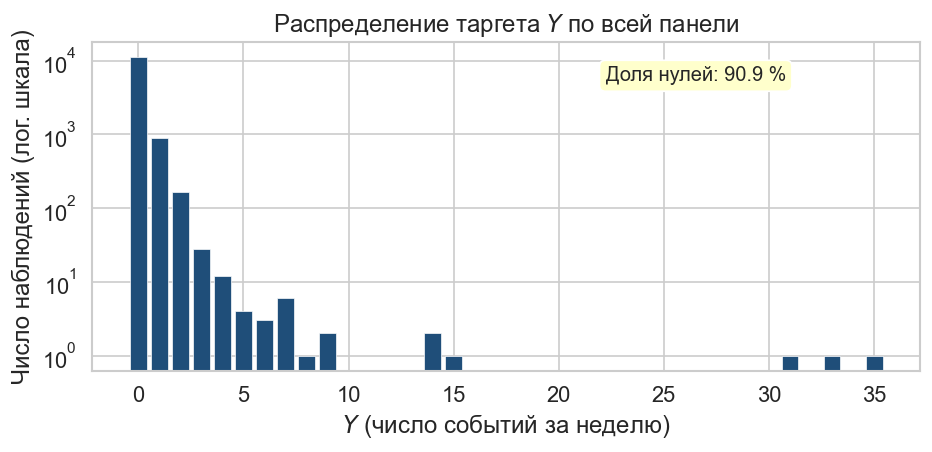

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = panel["Y"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#1F4E79",
       edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("$Y$ (число событий за неделю)")
ax.set_ylabel("Число наблюдений (лог. шкала)")
ax.set_title("Распределение таргета $Y$ по всей панели")
pct_zero = (panel["Y"] == 0).mean() * 100
ax.annotate(
    f"Доля нулей: {pct_zero:.1f} %", xy=(0.62, 0.88),
    xycoords="axes fraction", fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffffcc"),
)
fig.tight_layout()
plt.show()

---
## 2. Аналитический вывод градиентов $\mathcal{L}_{NB}(\theta)$

В этом разделе мы выведем частные производные функции потерь Negative Binomial
по предсказанным параметрам $\mu$ и $\alpha$, которые затем будут использованы
в ручной реализации обратного распространения.

### 2.1 Параметризация и лог-правдоподобие

Пусть $Y \sim \mathrm{NB}(\mu, \alpha)$ с функцией масс:

$$
P(Y = y \mid \mu, \alpha)
= \frac{\Gamma(y + r)}{\Gamma(y+1)\,\Gamma(r)}
  \left(\frac{r}{r + \mu}\right)^{r}
  \left(\frac{\mu}{r + \mu}\right)^{y},
\qquad r = \frac{1}{\alpha}.
$$

Введём обозначение $D = 1 + \alpha\mu$. Тогда:

$$
\frac{r}{r+\mu} = \frac{1}{D}, \qquad
\frac{\mu}{r+\mu} = \frac{\alpha\mu}{D}.
$$

Лог-правдоподобие одного наблюдения:

$$
\ell(y;\,\mu,\alpha)
= \ln\Gamma(y+r) - \ln\Gamma(y+1) - \ln\Gamma(r)
+ r\ln\frac{1}{D} + y\ln\frac{\alpha\mu}{D}.
$$

Функция потерь на мини-батче из $N$ наблюдений:

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \ell(y_i;\,\mu_i,\,\alpha_i).
$$

### 2.2 Градиент по $\mu$

Дифференцируем $\ell$ по $\mu$ (при фиксированном $\alpha$). Только два
последних слагаемых зависят от $\mu$:

$$
\frac{\partial \ell}{\partial \mu}
= r \cdot \frac{-\alpha}{D}
+ y \cdot \frac{\partial}{\partial \mu}\!\left[\ln(\alpha\mu) - \ln D\right]
= \frac{-r\alpha}{D}
+ y\!\left(\frac{1}{\mu} - \frac{\alpha}{D}\right).
$$

Подставляя $r\alpha = 1$:

$$
\frac{\partial \ell}{\partial \mu}
= \frac{-1}{D} + \frac{y}{\mu D}
= \frac{y - \mu}{\mu\,D}.
$$

Следовательно, градиент функции потерь для одного наблюдения:

$$
\boxed{\;
\frac{\partial \mathcal{L}}{\partial \mu}
= \frac{\mu - y}{\mu\,(1 + \alpha\mu)}
\;}
$$

### 2.3 Градиент по $\alpha$

Все слагаемые $\ell$ (кроме $-\ln\Gamma(y+1)$) зависят от $\alpha$ через
$r = 1/\alpha$. Обозначим $\psi(x) = \frac{d}{dx}\ln\Gamma(x)$ — функция
**дигамма**. Цепное правило: $\frac{\partial r}{\partial \alpha} = -\frac{1}{\alpha^2}$.

$$
\frac{\partial}{\partial \alpha}\bigl[\ln\Gamma(y+r) - \ln\Gamma(r)\bigr]
= \bigl[\psi(y+r) - \psi(r)\bigr]\cdot\!\left(-\frac{1}{\alpha^2}\right).
$$

$$
\frac{\partial}{\partial \alpha}\!\left[r\ln\frac{1}{D}\right]
= \frac{\ln D}{\alpha^2} - \frac{\mu}{\alpha D}.
$$

$$
\frac{\partial}{\partial \alpha}\!\left[y\ln\frac{\alpha\mu}{D}\right]
= \frac{y}{\alpha D}.
$$

Суммируя:

$$
\frac{\partial \ell}{\partial \alpha}
= \frac{1}{\alpha^2}\bigl[\psi(r) - \psi(y+r) + \ln D\bigr]
+ \frac{y - \mu}{\alpha D}.
$$

Итого для функции потерь:

$$
\boxed{\;
\frac{\partial \mathcal{L}}{\partial \alpha}
= \frac{1}{\alpha^2}\bigl[\psi(y+r) - \psi(r) - \ln D\bigr]
+ \frac{\mu - y}{\alpha\,(1 + \alpha\mu)}
\;}
$$

где $r = 1/\alpha$, $D = 1 + \alpha\mu$.

---
## 3. Реализация на чистом NumPy

Класс `NumpyHybridNB` повторяет архитектуру `EarthquakeNet`:

- Матрица эмбеддингов $\mathbf{E} \in \mathbb{R}^{C \times 8}$
- Два скрытых слоя: $64$ и $32$ нейрона с ReLU
- Выходной слой $\to$ Softplus $\to$ $(\mu, \alpha)$

Метод `backward()` реализует ручное обратное распространение ошибки
на основе выведенных выше градиентов.

In [9]:
class NumpyHybridNB:
    def __init__(self, num_cells, input_dim, emb_dim=8):
        self.emb_dim = emb_dim
        rng = np.random.default_rng(0)
        d0 = emb_dim + input_dim
        self.E     = (rng.standard_normal((num_cells, emb_dim)) * 0.01).astype(np.float32)
        self.W1    = (rng.standard_normal((64, d0))  * np.sqrt(2.0 / d0)).astype(np.float32)
        self.b1    = np.zeros(64, dtype=np.float32)
        self.W2    = (rng.standard_normal((32, 64))  * np.sqrt(2.0 / 64)).astype(np.float32)
        self.b2    = np.zeros(32, dtype=np.float32)
        self.W_out = (rng.standard_normal((2, 32))   * np.sqrt(2.0 / 32)).astype(np.float32)
        self.b_out = np.zeros(2, dtype=np.float32)
        self._cache = {}

    def load_from_pytorch(self, net):
        sd = {k: v.detach().cpu().numpy() for k, v in net.state_dict().items()}
        self.E     = sd['embedding.weight'].copy()
        self.W1    = sd['fc1.weight'].copy()
        self.b1    = sd['fc1.bias'].copy()
        self.W2    = sd['fc2.weight'].copy()
        self.b2    = sd['fc2.bias'].copy()
        self.W_out = sd['out.weight'].copy()
        self.b_out = sd['out.bias'].copy()

    @staticmethod
    def _softplus(x):
        return np.log1p(np.exp(np.clip(x, -20.0, 20.0)))

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -20.0, 20.0)))

    def forward(self, X_num, cell_idx):
        e     = self.E[cell_idx]                        # (N, emb)
        h0    = np.concatenate([e, X_num], axis=1)      # (N, emb+d)
        z1    = h0 @ self.W1.T + self.b1                # (N, 64)
        h1    = np.maximum(0.0, z1)                     # ReLU
        z2    = h1 @ self.W2.T + self.b2                # (N, 32)
        h2    = np.maximum(0.0, z2)                     # ReLU
        z_out = h2 @ self.W_out.T + self.b_out          # (N, 2)
        mu    = self._softplus(z_out[:, 0]) + 1e-8
        alpha = self._softplus(z_out[:, 1]) + 1e-8
        self._cache = dict(
            h0=h0, z1=z1, h1=h1, z2=z2, h2=h2,
            z_out=z_out, mu=mu, alpha=alpha, cell_idx=cell_idx,
        )
        return mu, alpha

    def nb_loss(self, mu, alpha, y):
        eps = 1e-8
        mu_c = np.clip(mu, eps, None)
        alpha_c = np.clip(alpha, eps, None)
        y_c = np.clip(y, 0.0, None)
        r = 1.0 / alpha_c
        D = 1.0 + alpha_c * mu_c
        log_prob = (
            gammaln(y_c + r) - gammaln(y_c + 1.0) - gammaln(r)
            + r * np.log(1.0 / (D + eps))
            + y_c * np.log(alpha_c * mu_c / (D + eps) + eps)
        )
        return float(-np.mean(log_prob))

    def backward(self, y):
        c = self._cache
        N = float(len(y))
        mu, alpha = c['mu'], c['alpha']
        eps = 1e-8
        r = 1.0 / np.clip(alpha, eps, None)
        D = 1.0 + alpha * mu

        dL_dmu    = (mu - y) / (mu * D)
        dL_dalpha = (
            (digamma(y + r) - digamma(r) - np.log(D)) / alpha**2
            + (mu - y) / (alpha * D)
        )

        sig0 = self._sigmoid(c['z_out'][:, 0])
        sig1 = self._sigmoid(c['z_out'][:, 1])
        dz   = np.column_stack([dL_dmu * sig0, dL_dalpha * sig1]) / N

        grads = {}
        grads['W_out'] = dz.T @ c['h2']
        grads['b_out'] = dz.sum(axis=0)

        dh2 = dz @ self.W_out
        dh2 *= (c['z2'] > 0).astype(np.float32)
        grads['W2'] = dh2.T @ c['h1']
        grads['b2'] = dh2.sum(axis=0)

        dh1 = dh2 @ self.W2
        dh1 *= (c['z1'] > 0).astype(np.float32)
        grads['W1'] = dh1.T @ c['h0']
        grads['b1'] = dh1.sum(axis=0)

        return grads

print('Класс NumpyHybridNB определён.')

Класс NumpyHybridNB определён.


---
## 4. Кросс-верификация: PyTorch vs NumPy

Загрузим данные, инициализируем PyTorch-модель `EarthquakeNet`, перенесём
веса в `NumpyHybridNB` и убедимся, что:

1. **Прямой проход**: значения $\mu$ и $\alpha$ совпадают.
2. **Функция потерь**: скалярное значение $\mathcal{L}$ совпадает.
3. **Градиенты**: $\partial\mathcal{L}/\partial\mathbf{W}$ совпадают с точностью до числовых стабилизаторов $\varepsilon$.

In [10]:
FEATURES = [
    "Y_lag1", "mag_max_lag1", "mag_min_lag1",
    "mag_max_roll4", "count_roll12", "energy_roll8", "weeks_since_m45",
]

work = panel.dropna(subset=["week", "cell_id", "Y"]).copy()
work = work.sort_values("week").reset_index(drop=True)

n = len(work)
n_train_full = int(np.floor(0.8 * n))
n_val = max(1, int(np.floor(0.1 * n_train_full)))

train_full = work.iloc[:n_train_full].reset_index(drop=True)
test_df     = work.iloc[n_train_full:].reset_index(drop=True)
train_df    = train_full.iloc[:-n_val].reset_index(drop=True)
val_df      = train_full.iloc[-n_val:].reset_index(drop=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES].fillna(0).astype(float)).astype(np.float32)
X_val   = scaler.transform(val_df[FEATURES].fillna(0).astype(float)).astype(np.float32)
X_test  = scaler.transform(test_df[FEATURES].fillna(0).astype(float)).astype(np.float32)

y_train = train_df["Y"].to_numpy(dtype=np.float32)
y_val   = val_df["Y"].to_numpy(dtype=np.float32)
y_test  = test_df["Y"].to_numpy(dtype=np.float64)

cell_classes = pd.Index(train_df["cell_id"].astype(str).unique())
cell_map = {c: i for i, c in enumerate(cell_classes)}
unk = len(cell_classes)
num_cells = unk + 1

c_train = train_df["cell_id"].astype(str).map(cell_map).fillna(unk).astype(np.int64).to_numpy()
c_val   = val_df["cell_id"].astype(str).map(cell_map).fillna(unk).astype(np.int64).to_numpy()
c_test  = test_df["cell_id"].astype(str).map(cell_map).fillna(unk).astype(np.int64).to_numpy()

print(f"Train: {len(train_df):,}   Val: {len(val_df):,}   Test: {len(test_df):,}")
print(f"Num cells (включая UNK): {num_cells}")

Train: 8,947   Val: 994   Test: 2,486
Num cells (включая UNK): 18


In [11]:
torch.manual_seed(42)
net = EarthquakeNet(num_cells=num_cells, input_dim=len(FEATURES), emb_dim=8).to("cpu")
net.eval()

np_model = NumpyHybridNB(num_cells=num_cells, input_dim=len(FEATURES), emb_dim=8)
np_model.load_from_pytorch(net)

batch_x = X_test[:64]
batch_c = c_test[:64]
batch_y = y_test[:64]

with torch.no_grad():
    mu_pt, alpha_pt = net(torch.from_numpy(batch_x), torch.from_numpy(batch_c))
    mu_pt_np    = mu_pt.numpy().copy()
    alpha_pt_np = alpha_pt.numpy().copy()
    loss_pt = NBLoss()(
        mu_pt, alpha_pt, torch.from_numpy(batch_y.astype(np.float32))
    ).item()

mu_np, alpha_np = np_model.forward(batch_x, batch_c)
loss_np = np_model.nb_loss(mu_np, alpha_np, batch_y)

print("=== Прямой проход ===")
print(f"  mu    max|diff| = {np.max(np.abs(mu_pt_np - mu_np)):.2e}")
print(f"  alpha max|diff| = {np.max(np.abs(alpha_pt_np - alpha_np)):.2e}")
print(f"  Loss PyTorch    = {loss_pt:.8f}")
print(f"  Loss NumPy      = {loss_np:.8f}")
print(f"  Loss |diff|     = {abs(loss_pt - loss_np):.2e}")
print(f"  np.allclose(mu)    : {np.allclose(mu_pt_np, mu_np, atol=1e-5)}")
print(f"  np.allclose(alpha) : {np.allclose(alpha_pt_np, alpha_np, atol=1e-5)}")

=== Прямой проход ===
  mu    max|diff| = 5.96e-08
  alpha max|diff| = 5.96e-08
  Loss PyTorch    = 0.71608299
  Loss NumPy      = 0.71608295
  Loss |diff|     = 4.26e-08
  np.allclose(mu)    : True
  np.allclose(alpha) : True


In [12]:
net.eval()
net.zero_grad()
mu_t, alpha_t = net(torch.from_numpy(batch_x), torch.from_numpy(batch_c))
loss_t = NBLoss()(mu_t, alpha_t, torch.from_numpy(batch_y.astype(np.float32)))
loss_t.backward()

grads_np = np_model.backward(batch_y)

grad_names = [
    ("out.weight", "W_out"),
    ("out.bias",   "b_out"),
    ("fc2.weight", "W2"),
    ("fc2.bias",   "b2"),
    ("fc1.weight", "W1"),
    ("fc1.bias",   "b1"),
]

print("=== Градиенты (PyTorch autograd vs NumPy manual) ===")
params = dict(net.named_parameters())
for pt_name, np_name in grad_names:
    pt_grad = params[pt_name].grad.detach().cpu().numpy()
    diff = np.max(np.abs(pt_grad - grads_np[np_name]))
    tag = "OK" if diff < 1e-4 else "MISMATCH"
    print(f"  d({pt_name:14s})  max|diff| = {diff:.2e}  [{tag}]")

=== Градиенты (PyTorch autograd vs NumPy manual) ===
  d(out.weight    )  max|diff| = 1.53e-08  [OK]
  d(out.bias      )  max|diff| = 2.21e-08  [OK]
  d(fc2.weight    )  max|diff| = 4.88e-09  [OK]
  d(fc2.bias      )  max|diff| = 2.96e-09  [OK]
  d(fc1.weight    )  max|diff| = 1.32e-09  [OK]
  d(fc1.bias      )  max|diff| = 5.51e-10  [OK]


---
## 5. Обучение и визуализация предсказаний

Обучим PyTorch-модель на **10 демонстрационных эпохах**, получим предсказания
$\mu_i$ на тестовой выборке, рассчитаем метрики и построим итоговый график
с доверительным интервалом на основе предсказанного $\alpha$.

In [18]:
DEMO_EPOCHS = 10
BATCH_SIZE  = 64

torch.manual_seed(42)
model     = EarthquakeNet(num_cells=num_cells, input_dim=len(FEATURES), emb_dim=8).to(DEVICE)
criterion = NBLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader = DataLoader(
    EarthquakeDataset(X_train, c_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    EarthquakeDataset(X_val, c_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False,
)

history = {"epoch": [], "train_loss": [], "val_loss": []}

for epoch in range(1, DEMO_EPOCHS + 1):
    model.train()
    tr_sum, tr_n = 0.0, 0
    for xb, cb, yb in train_loader:
        xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        mu, alpha = model(xb, cb)
        loss = criterion(mu, alpha, yb)
        loss.backward()
        optimizer.step()
        tr_sum += loss.item() * yb.shape[0]
        tr_n   += yb.shape[0]

    model.eval()
    va_sum, va_n = 0.0, 0
    with torch.no_grad():
        for xb, cb, yb in val_loader:
            xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            mu, alpha = model(xb, cb)
            va_sum += criterion(mu, alpha, yb).item() * yb.shape[0]
            va_n   += yb.shape[0]

    tl = tr_sum / max(tr_n, 1)
    vl = va_sum / max(va_n, 1)
    history["epoch"].append(epoch)
    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    print(f"Epoch {epoch:02d}/{DEMO_EPOCHS} | Train Loss: {tl:.6f} | Val Loss: {vl:.6f}")

Epoch 01/10 | Train Loss: 0.427534 | Val Loss: 0.368229
Epoch 02/10 | Train Loss: 0.325296 | Val Loss: 0.362535
Epoch 03/10 | Train Loss: 0.312182 | Val Loss: 0.359829
Epoch 04/10 | Train Loss: 0.309725 | Val Loss: 0.356494
Epoch 05/10 | Train Loss: 0.307418 | Val Loss: 0.356442
Epoch 06/10 | Train Loss: 0.304010 | Val Loss: 0.357274
Epoch 07/10 | Train Loss: 0.304190 | Val Loss: 0.359061
Epoch 08/10 | Train Loss: 0.302524 | Val Loss: 0.356923
Epoch 09/10 | Train Loss: 0.302823 | Val Loss: 0.358587
Epoch 10/10 | Train Loss: 0.301273 | Val Loss: 0.354409


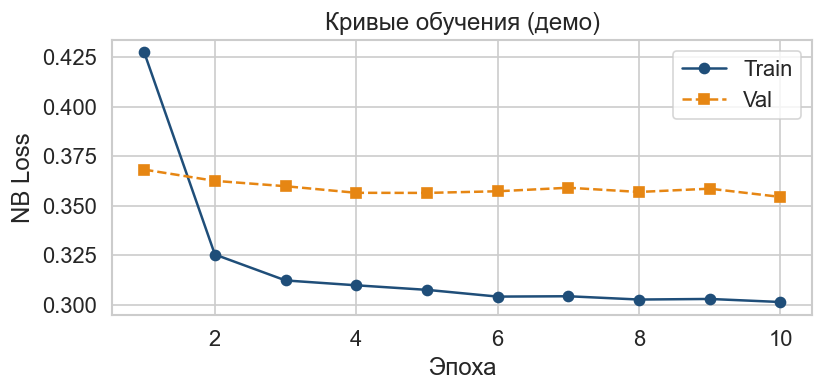

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history["epoch"], history["train_loss"], "o-",  label="Train", color="#1F4E79")
ax.plot(history["epoch"], history["val_loss"],   "s--", label="Val",   color="#E68613")
ax.set_xlabel("Эпоха")
ax.set_ylabel("NB Loss")
ax.set_title("Кривые обучения (демо)")
ax.legend()
fig.tight_layout()
plt.show()

In [15]:
model.eval()
test_loader = DataLoader(
    EarthquakeDataset(X_test, c_test, y_test.astype(np.float32)),
    batch_size=BATCH_SIZE, shuffle=False,
)

mu_parts, alpha_parts = [], []
with torch.no_grad():
    for xb, cb, _ in test_loader:
        xb, cb = xb.to(DEVICE), cb.to(DEVICE)
        mu, alpha = model(xb, cb)
        mu_parts.append(mu.cpu().numpy())
        alpha_parts.append(alpha.cpu().numpy())

mu_pred    = np.clip(np.concatenate(mu_parts), 1e-9, None)
alpha_pred = np.concatenate(alpha_parts)

mae  = mean_absolute_error(y_test, mu_pred)
rmse = np.sqrt(mean_squared_error(y_test, mu_pred))
mpd  = mean_poisson_deviance(y_test, mu_pred)

print(f"MAE                   = {mae:.4f}")
print(f"RMSE                  = {rmse:.4f}")
print(f"Mean Poisson Deviance = {mpd:.4f}")

MAE                   = 0.2109
RMSE                  = 0.5242
Mean Poisson Deviance = 0.5271


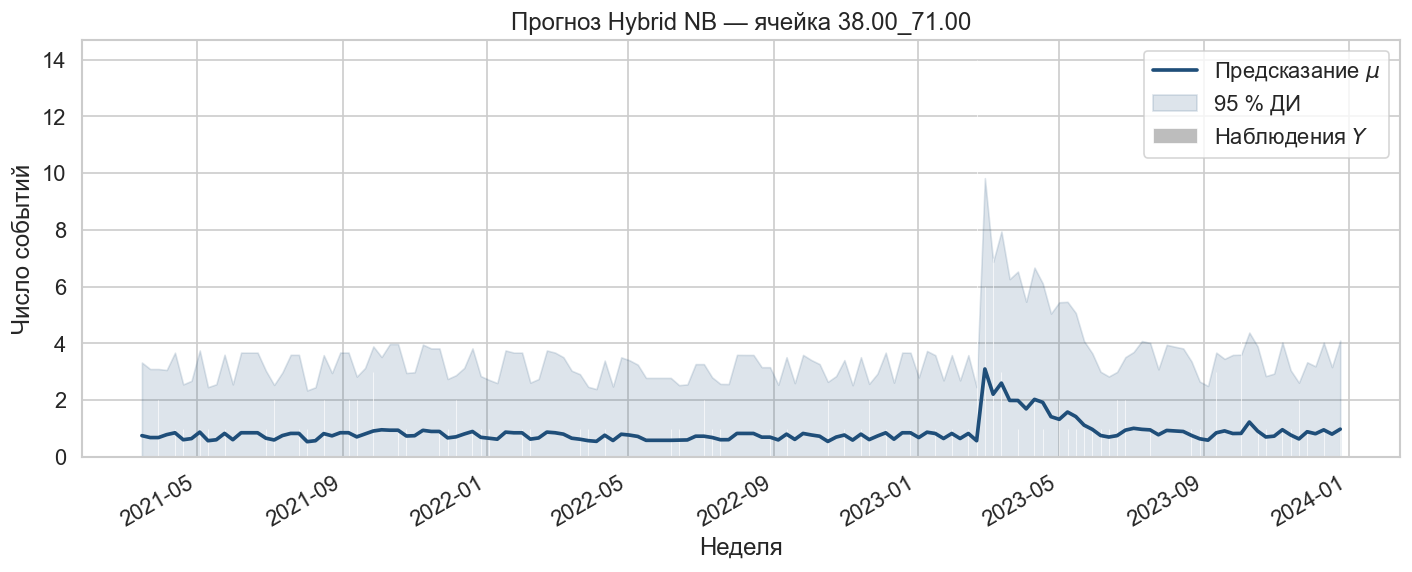

In [16]:
test_vis = test_df.copy()
test_vis['mu_pred']    = mu_pred
test_vis['alpha_pred'] = alpha_pred

cell_totals = test_vis.groupby('cell_id')['Y'].sum()
best_cell = cell_totals.idxmax()
sub = test_vis[test_vis['cell_id'] == best_cell].sort_values('week').copy()

mu_arr  = sub['mu_pred'].to_numpy()
alp_arr = sub['alpha_pred'].to_numpy()
var_pred = mu_arr + alp_arr * mu_arr**2
std_pred = np.sqrt(np.clip(var_pred, 0, None))

fig, ax = plt.subplots(figsize=(12, 5))
weeks = sub['week'].to_numpy()
y_obs = sub['Y'].to_numpy()

ax.bar(weeks, y_obs, width=5, color='#bdbdbd', edgecolor='white',
       linewidth=0.4, label='Наблюдения $Y$', zorder=2)
ax.plot(weeks, mu_arr, color='#1F4E79', linewidth=2.2,
        label=r'Предсказание $\mu$', zorder=3)
ax.fill_between(
    weeks,
    np.maximum(mu_arr - 1.96 * std_pred, 0),
    mu_arr + 1.96 * std_pred,
    color='#1F4E79', alpha=0.15, label='95 % ДИ', zorder=1,
)
ax.set_xlabel('Неделя')
ax.set_ylabel('Число событий')
ax.set_title(f'Прогноз Hybrid NB — ячейка {best_cell}')
ax.legend(frameon=True)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()